In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [17]:
# Compare churned vs retained customers
churn_count = df['Churn'].value_counts()
print(churn_count)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [5]:
# Identify major factors affecting churn
contract_churn = pd.crosstab(df['Contract'], df['Churn'])
print(contract_churn)

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48


In [6]:
internet_churn = pd.crosstab(df['InternetService'], df['Churn'])
print(internet_churn)

Churn              No   Yes
InternetService            
DSL              1962   459
Fiber optic      1799  1297
No               1413   113


In [7]:
monthly_charges = df.groupby('Churn')['MonthlyCharges'].mean()
print(monthly_charges)

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


In [8]:
tenure_analysis = df.groupby('Churn')['tenure'].mean()
print(tenure_analysis)

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64


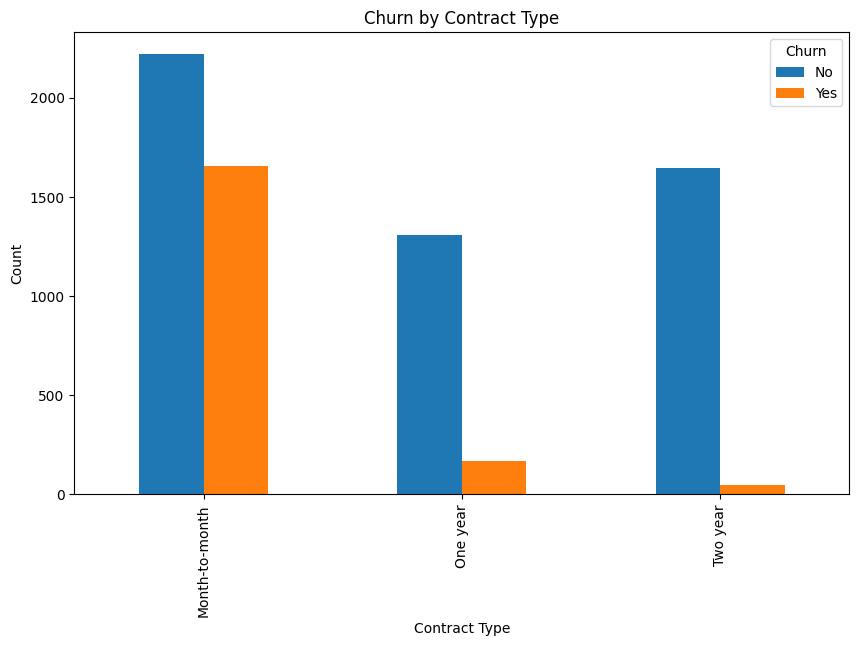

In [9]:
# Analyze impact of: contract type, monthly charges, support calls
contract_churn.plot(kind = 'bar', figsize = (10, 6))
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.title('Churn by Contract Type')
plt.show()

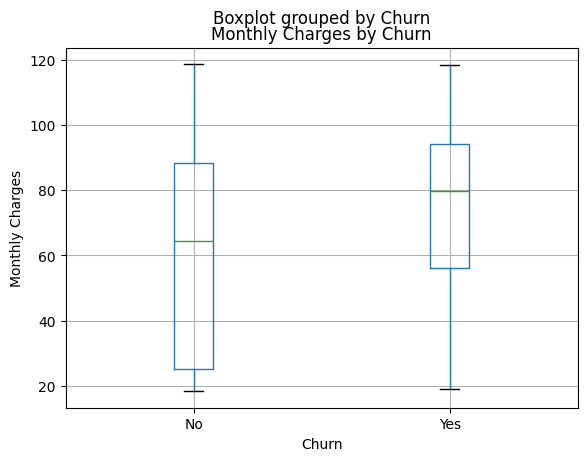

In [10]:
df.boxplot(column = 'MonthlyCharges', by = 'Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.title('Monthly Charges by Churn')
plt.show()

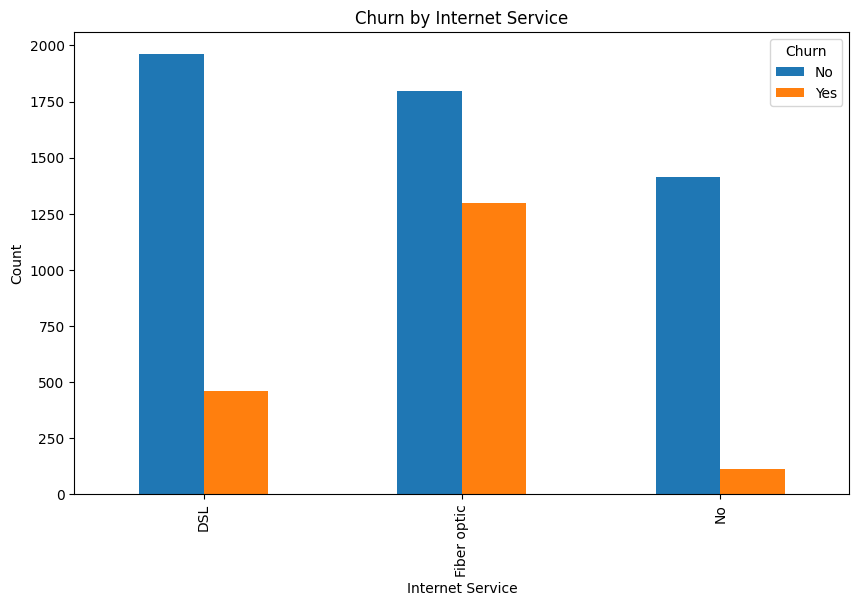

In [11]:
internet_churn.plot(kind = 'bar', figsize = (10, 6))
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.title('Churn by Internet Service')
plt.show()

visualization

<function matplotlib.pyplot.show(close=None, block=None)>

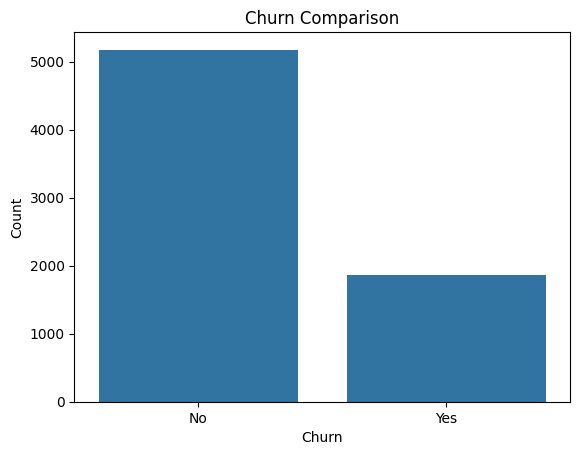

In [12]:
# churn comparison charts
sns.countplot(x = 'Churn', data = df)
plt.xlabel('Churn')
plt.ylabel('Count')
plt.title('Churn Comparison')
plt.show

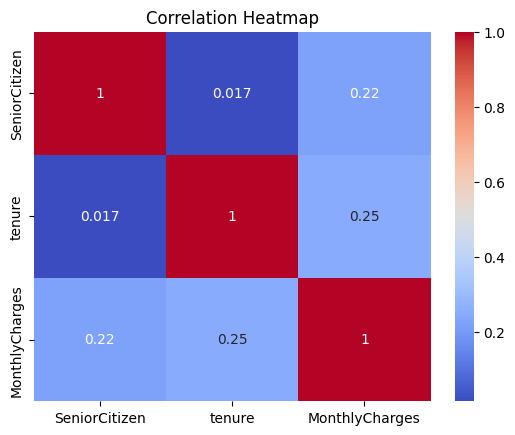

In [14]:
# correlation heatmap
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

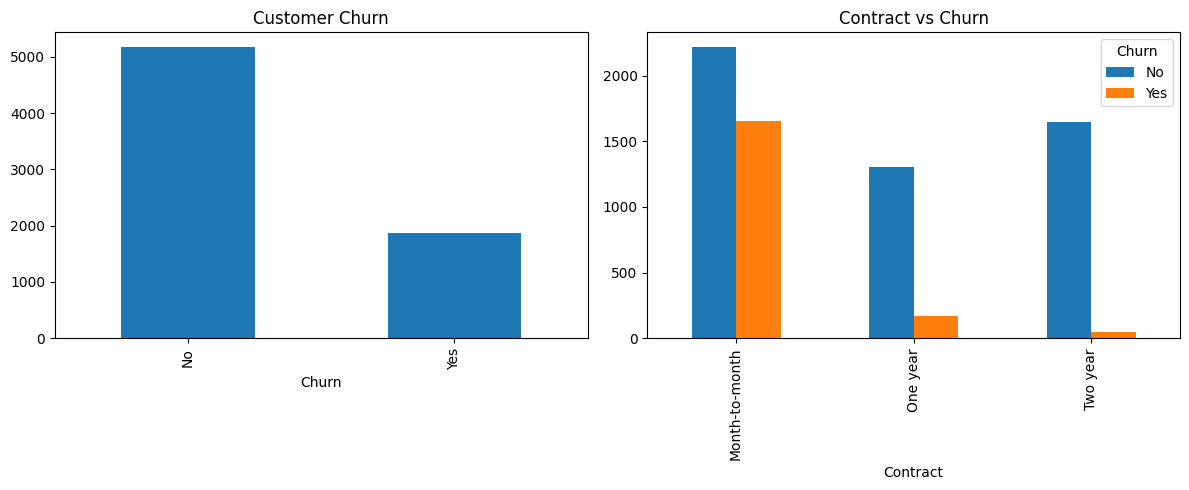

In [18]:
# churn dashboard
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Churn count
churn_count.plot(kind="bar", ax=axes[0])
axes[0].set_title("Customer Churn")

# Contract churn
contract_churn.plot(kind="bar", ax=axes[1])
axes[1].set_title("Contract vs Churn")

plt.tight_layout()

plt.show()

In [19]:
# Recommendations to reduce churn
print("""
Recommendations:

1. Encourage long-term contracts because month-to-month customers churn more.

2. Reduce monthly charges or provide better value plans.

3. Improve customer support quality.

4. Provide loyalty rewards for long-term customers.

5. Offer personalized retention offers to high-risk customers.
""")


Recommendations:

1. Encourage long-term contracts because month-to-month customers churn more.

2. Reduce monthly charges or provide better value plans.

3. Improve customer support quality.

4. Provide loyalty rewards for long-term customers.

5. Offer personalized retention offers to high-risk customers.

